# Dinov3 Model Training + Classfication Layer

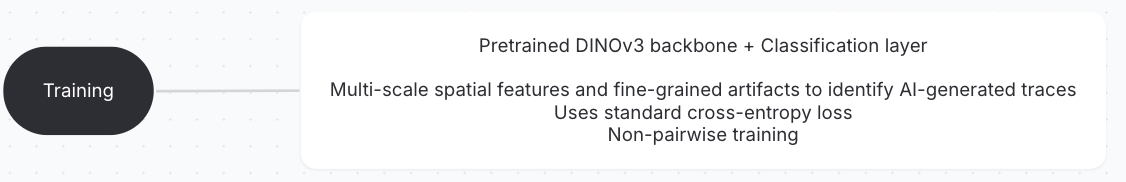
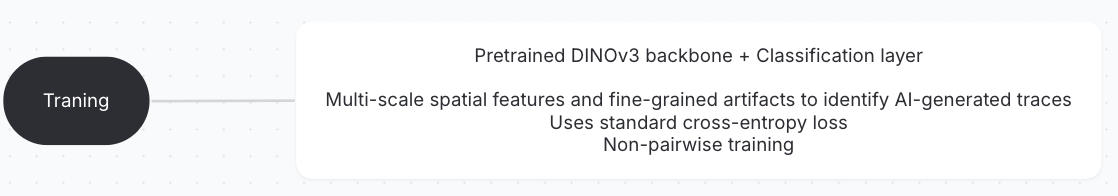

In [1]:
!git clone https://github.com/facebookresearch/dinov3.git

Cloning into 'dinov3'...
remote: Enumerating objects: 583, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 583 (delta 0), reused 0 (delta 0), pack-reused 580 (from 2)
Receiving objects: 100% (583/583), 12.97 MiB | 35.51 MiB/s, done.
Resolving deltas: 100% (204/204), done.


## Load imports

In [58]:
import torch
import pickle
import random

from PIL import Image
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split

import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load Dinov3 backbone model

In [4]:
REPO_DIR = "/kaggle/working/dinov3"

dinov3_vitb16 = torch.hub.load(REPO_DIR, 'dinov3_vitb16', 
                               source='local', 
                               weights="/kaggle/input/models/adityal0/dinov3/pytorch/default/1/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth")

Downloading: "file:///kaggle/input/models/adityal0/dinov3/pytorch/default/1/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


100%|██████████| 327M/327M [00:05<00:00, 65.5MB/s] 


## Set up images for training

In [5]:
# loading the image paths

with open('/kaggle/input/datasets/adityal0/image-paths/final_fake_image_paths.pkl', 'rb') as f:
    final_fake_image_paths = pickle.load(f)

with open('/kaggle/input/datasets/adityal0/image-paths/real_image_paths.pkl', 'rb') as f:
    real_image_paths = pickle.load(f)

In [22]:
# dataloaders

class FinalTrainingDataset(Dataset):
    def __init__(self, real_image_paths, fake_image_paths, image_size=224):
        self.real_paths = real_image_paths
        self.fake_paths = fake_image_paths

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        

    def __len__(self):
        return max(len(self.real_paths), len(self.fake_paths))

    def __getitem__(self, idx):
        # taking a random image and label
        if idx % 2 == 0:
            img_path = random.choice(self.real_paths)
            label = 1
        else:
            img_path = random.choice(self.fake_paths)
            label = 0

        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

In [23]:
# create data loaders
dataset = FinalTrainingDataset(real_image_paths=real_image_paths,fake_image_paths=final_fake_image_paths) #final_training_features=fake features
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [8]:
# checking image shape and label shape in the dataloader
for sample, label in dataloader:
    print(sample.shape)
    print(label.shape)

    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


## Metrics

In [9]:
def compute_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)  # predicted class
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

def compute_ap(outputs, labels):
    # Convert labels to CPU numpy
    labels_np = labels.cpu().numpy()
    # Get predicted probability for class 1 (real)
    probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
    return average_precision_score(labels_np, probs)

# Model 1

In [10]:
# load the dinov3 backbone model 
# we add classification layer

class DinoDetector(torch.nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.classifier = torch.nn.Linear(768, 2) # binary classification

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [11]:
DEVICE = "cuda:0"

In [12]:
model = DinoDetector(dinov3_vitb16).to(DEVICE)

In [13]:
model

DinoDetector(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (rope_embed): RopePositionEmbedding()
    (blocks): ModuleList(
      (0-11): 12 x SelfAttentionBlock(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SelfAttention(
          (qkv): LinearKMaskedBias(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inpla

In [20]:
# hyperparameters

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)
num_epochs = 100
batch_size = 16

In [24]:
# testing for single batch 

images, labels = next(iter(dataloader))
print(images.shape)  # should be [B,3,224,224]
print(labels.shape)  # should be [B]
outputs = model(images.to(DEVICE))
print(outputs.shape) # should be [B,2]
loss = criterion(outputs, labels.to(DEVICE))
print(loss)

torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.Size([32, 2])
tensor(0.7952, device='cuda:0', grad_fn=<NllLossBackward0>)


In [25]:
# training model
for epoch in range(num_epochs):
    model.to(DEVICE)
    model.train()
    
    epoch_loss = 0.0
    epoch_acc = 0.0
    epoch_ap = 0.0


    for images, labels in dataloader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += compute_accuracy(outputs, labels)
        epoch_ap += compute_ap(outputs, labels)

    epoch_acc /= len(dataloader)
    epoch_ap /= len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} AP: {epoch_ap:.4f}")

Epoch [1/100] Loss: 7.2508 Acc: 0.5042 AP: 0.5648
Epoch [2/100] Loss: 7.5127 Acc: 0.4885 AP: 0.5181
Epoch [3/100] Loss: 7.2614 Acc: 0.4698 AP: 0.5270
Epoch [4/100] Loss: 7.6560 Acc: 0.4604 AP: 0.5165
Epoch [5/100] Loss: 7.2657 Acc: 0.4854 AP: 0.5240
Epoch [6/100] Loss: 7.3061 Acc: 0.4802 AP: 0.5463
Epoch [7/100] Loss: 7.5214 Acc: 0.4510 AP: 0.5301
Epoch [8/100] Loss: 7.6562 Acc: 0.4323 AP: 0.4732
Epoch [9/100] Loss: 7.2750 Acc: 0.4740 AP: 0.5224
Epoch [10/100] Loss: 7.2583 Acc: 0.5135 AP: 0.5409
Epoch [11/100] Loss: 7.5087 Acc: 0.4698 AP: 0.5087
Epoch [12/100] Loss: 7.4484 Acc: 0.4562 AP: 0.4977
Epoch [13/100] Loss: 7.3894 Acc: 0.4854 AP: 0.5248
Epoch [14/100] Loss: 7.3168 Acc: 0.4865 AP: 0.5224
Epoch [15/100] Loss: 7.2080 Acc: 0.5031 AP: 0.5610
Epoch [16/100] Loss: 7.4231 Acc: 0.4708 AP: 0.5211
Epoch [17/100] Loss: 7.3504 Acc: 0.5146 AP: 0.5191
Epoch [18/100] Loss: 7.2886 Acc: 0.5073 AP: 0.5709
Epoch [19/100] Loss: 7.5961 Acc: 0.4188 AP: 0.5148
Epoch [20/100] Loss: 7.7135 Acc: 0.4229 

KeyboardInterrupt: 

# Model 2

In [27]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
import torch
import numpy as np

In [48]:
class DinoDetector_V2(torch.nn.Module):
    def __init__(self, backbone, dropout=0.2):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout)
        self.classifier = torch.nn.Linear(768, 2) # binary classification

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [49]:
model_2 = DinoDetector_V2(dinov3_vitb16)
model_2 = model_2.to(DEVICE)

In [36]:
# Example forward pass
images = torch.randn(4, 3, 224, 224).to('cuda')
logits = model_2(images)  # Output: [4, 2]
probs = torch.softmax(logits, dim=1)  # Get probabilities
predictions = torch.argmax(logits, dim=1)  # Get class predictions

In [41]:
predictions

tensor([0, 0, 0, 0], device='cuda:0')

In [50]:
class SimpleTrainingDataset(Dataset):
    def __init__(self, real_image_paths, fake_image_paths, image_size=224, seed=42):
        self.real_paths = list(real_image_paths)
        self.fake_paths = list(fake_image_paths)
        
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        
        # random seed
        rng = np.random.RandomState(seed)
        
        num_real = len(self.real_paths)
        num_fake = len(self.fake_paths)
        max_len = max(num_real, num_fake)
        
        # Sample with replacement to match lengths
        real_indices = rng.choice(num_real, size=max_len, replace=True)
        fake_indices = rng.choice(num_fake, size=max_len, replace=True)
        
        # create image with real:1 and fake:0
        self.images = []
        for i in range(max_len):
            self.images.append((self.real_paths[real_indices[i]], 1))
            self.images.append((self.fake_paths[fake_indices[i]], 0))
        
        # Shuffle images (non-pairwise training)
        rng.shuffle(self.images)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

In [51]:
dataset = SimpleTrainingDataset(real_image_paths, final_fake_image_paths)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [42]:
for image, label in loader:
    print(image)
    print(label)
    break

tensor([[[[-0.1143, -0.0972, -0.0972,  ...,  0.9988,  0.6563,  0.5022],
          [-0.2171, -0.1828, -0.1828,  ...,  1.1529,  0.7762,  0.4508],
          [-0.2342, -0.1828, -0.1486,  ...,  0.9988,  0.8276,  0.6563],
          ...,
          [-0.3369,  0.3138,  0.1254,  ...,  0.6563,  0.1083,  0.3481],
          [-0.2342,  0.4166,  0.0569,  ...,  0.5878,  0.2111,  0.1083],
          [ 0.0056,  0.5364, -0.0458,  ...,  0.3309,  0.4337, -0.0801]],

         [[-0.3200, -0.3025, -0.3025,  ...,  1.2731,  0.8880,  0.7129],
          [-0.4251, -0.3901, -0.3901,  ...,  1.4657,  1.0805,  0.7654],
          [-0.4426, -0.3901, -0.3550,  ...,  1.3081,  1.2031,  1.0280],
          ...,
          [-0.6877,  0.0826, -0.0224,  ...,  0.6604,  0.0651,  0.2402],
          [-0.5476,  0.2227, -0.0749,  ...,  0.5728,  0.1702, -0.0049],
          [-0.2675,  0.3452, -0.1800,  ...,  0.3277,  0.3803, -0.1975]],

         [[-0.1661, -0.1487, -0.1661,  ...,  1.6988,  1.2980,  1.1062],
          [-0.2881, -0.2707, -

In [52]:
from tqdm import tqdm

# Hyperparameters
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=5e-5, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
num_epochs = 100
batch_size = 16

# Move model to device once
model_2 = model_2.to(DEVICE)

In [53]:
# Training loop
for epoch in range(num_epochs):
    model_2.train()
    
    epoch_loss = 0.0
    epoch_acc = 0.0
    epoch_ap = 0.0
    num_batches = 0
    
    # Progress bar
    pbar = tqdm(loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Forward pass
        outputs = model_2(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        epoch_loss += loss.item()
        epoch_acc += compute_accuracy(outputs, labels)
        epoch_ap += compute_ap(outputs, labels)
        num_batches += 1
        
        # Update progress bar
        pbar.set_postfix({
            'loss': epoch_loss / num_batches,
            'acc': epoch_acc / num_batches,
            'ap': epoch_ap / num_batches
        })
    
    # Average metrics
    epoch_loss /= num_batches
    epoch_acc /= num_batches
    epoch_ap /= num_batches
    
    # Learning rate scheduling
    scheduler.step(epoch_ap)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | AP: {epoch_ap:.4f}")
    
    # # Optional: Save best model
    # if epoch_ap > best_ap:
    #     best_ap = epoch_ap
    #     torch.save(model.state_dict(), 'best_model.pth')

Epoch [1/100]: 100%|██████████| 38/38 [00:27<00:00,  1.36it/s, loss=0.489, acc=0.743, ap=0.81] 


Epoch [1/100] Loss: 0.4886 | Acc: 0.7434 | AP: 0.8100


Epoch [2/100]: 100%|██████████| 38/38 [00:26<00:00,  1.41it/s, loss=0.0989, acc=1, ap=1]


Epoch [2/100] Loss: 0.0989 | Acc: 1.0000 | AP: 1.0000


Epoch [3/100]:  18%|█▊        | 7/38 [00:05<00:24,  1.27it/s, loss=0.0612, acc=1, ap=1]


KeyboardInterrupt: 

# Model 3

In [65]:
class DinoDetector_V3(torch.nn.Module):
    """
    Normal architecture with dinvo3 backbone
    Linear classfication layer
    """
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        # self.dropout = nn.Dropout(dropout)
        self.classifier = torch.nn.Linear(768, 2) # binary classification

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [66]:
model_3 = DinoDetector_V3(dinov3_vitb16)
model_3 = model_3.to(DEVICE)

In [67]:
# Hyperparameters
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=5e-7, momentum=0.9) #5e-7 given in the paper
num_epochs = 100
batch_size = 8

In [68]:
# split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {train_size} images | Val: {val_size} images")

Train: 480 images | Val: 120 images


In [69]:
for img, feat in train_loader:
    print(img, feat)
    break

tensor([[[[ 1.1358,  1.4098,  1.9749,  ..., -0.9705, -1.1247, -1.2445],
          [ 0.6563,  0.4508,  0.9646,  ..., -1.1589, -1.2274, -1.3302],
          [ 0.3481,  0.1768,  0.4337,  ..., -1.3473, -1.2959, -1.4500],
          ...,
          [-0.7822, -0.6281, -0.8678,  ..., -0.6281, -0.7650, -0.8678],
          [-0.6452, -0.4739, -0.1828,  ..., -0.3883, -0.6452, -0.5938],
          [ 1.3413,  1.7180,  1.7694,  ..., -0.3027, -0.5767, -0.5082]],

         [[ 1.2906,  1.5707,  2.1485,  ..., -0.8627, -1.0203, -1.1429],
          [ 0.8004,  0.5903,  1.1155,  ..., -1.0553, -1.1253, -1.2304],
          [ 0.4853,  0.3102,  0.5728,  ..., -1.2479, -1.1954, -1.3529],
          ...,
          [-0.6702, -0.5126, -0.7577,  ..., -0.5126, -0.6527, -0.7577],
          [-0.5301, -0.3550, -0.0574,  ..., -0.2675, -0.5301, -0.4776],
          [ 1.5007,  1.8859,  1.9384,  ..., -0.1800, -0.4601, -0.3901]],

         [[ 1.5071,  1.7860,  2.3611,  ..., -0.6367, -0.7936, -0.9156],
          [ 1.0191,  0.8099,  

In [70]:
for epoch in range(num_epochs):
    model_3.train()
    model_3.to(DEVICE)
    
    train_loss = 0.0
    train_acc = 0.0
    train_ap = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")
    
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model_3(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += compute_accuracy(outputs, labels)
        train_ap += compute_ap(outputs, labels)
        num_batches += 1
        
        pbar.set_postfix({
            'loss': train_loss / num_batches,
            'acc': train_acc / num_batches,
            'ap': train_ap / num_batches
        })
    
    train_loss /= num_batches
    train_acc /= num_batches
    train_ap /= num_batches
    
    # Validation to detect overfitting)
    model_3.eval()
    val_loss = 0.0
    val_acc = 0.0
    val_ap = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model_3(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            val_acc += compute_accuracy(outputs, labels)
            val_ap += compute_ap(outputs, labels)
            val_batches += 1
    
    val_loss /= val_batches
    val_acc /= val_batches
    val_ap /= val_batches
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AP: {train_ap:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AP: {val_ap:.4f}")

Epoch [1/100]: 100%|██████████| 60/60 [00:21<00:00,  2.76it/s, loss=0.697, acc=0.533, ap=0.588]


Epoch [1/100] Train Loss: 0.6970 | Acc: 0.5333 | AP: 0.5876 | Val Loss: 0.6929 | Acc: 0.5417 | AP: 0.6131


Epoch [2/100]: 100%|██████████| 60/60 [00:21<00:00,  2.81it/s, loss=0.695, acc=0.529, ap=0.604]


Epoch [2/100] Train Loss: 0.6950 | Acc: 0.5292 | AP: 0.6041 | Val Loss: 0.6904 | Acc: 0.5417 | AP: 0.6156


Epoch [3/100]: 100%|██████████| 60/60 [00:20<00:00,  2.95it/s, loss=0.691, acc=0.544, ap=0.621]


...

Epoch [54/100] Train Loss: 0.5748 | Acc: 0.9708 | AP: 0.9992 | Val Loss: 0.5760 | Acc: 0.9333 | AP: 0.9929


Epoch [55/100]: 100%|██████████| 60/60 [00:20<00:00,  2.88it/s, loss=0.575, acc=0.971, ap=1]


Epoch [55/100] Train Loss: 0.5745 | Acc: 0.9708 | AP: 1.0000 | Val Loss: 0.5740 | Acc: 0.9333 | AP: 0.9929


Epoch [56/100]:  77%|███████▋  | 46/60 [00:16<00:04,  2.82it/s, loss=0.571, acc=0.967, ap=0.998]


KeyboardInterrupt: 

In [71]:
torch.save(model_3.state_dict(), 'model_1.pth')

In [73]:
# Save just the weights
torch.save(model_3.state_dict(), 'final_model.pth')
 
# Or save entire model
torch.save(model_3, 'final_model_full.pth')

In [72]:
def predict_single_image(image_path):
    """Predict on a single image"""
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        outputs = model_3(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        prediction = torch.argmax(probabilities, dim=1)
    
    prob_fake = probabilities[0, 0].item()  # Probability it's fake
    prob_real = probabilities[0, 1].item()  # Probability it's real
    pred_label = "Real" if prediction.item() == 1 else "Fake"
    
    print(f"Image: {image_path}")
    print(f"Prediction: {pred_label}")
    print(f"Confidence: {max(prob_fake, prob_real):.4f}")
    print(f"Fake: {prob_fake:.4f} | Real: {prob_real:.4f}")
    print()
    
    return pred_label, prob_real, prob_fake

predict_single_image('/kaggle/input/datasets/adityal0/uncovai-dataset/real_images/ID_0999.jpg')

Image: /kaggle/input/datasets/adityal0/uncovai-dataset/real_images/ID_0999.jpg
Prediction: Real
Confidence: 0.5955
Fake: 0.4045 | Real: 0.5955



('Real', 0.5955100655555725, 0.4044899344444275)

In [77]:
predict_single_image('/kaggle/input/datasets/adityal0/uncovai-dataset/diffusion_fake_images/diffusion_fake_images/ID_0013.jpg')

Image: /kaggle/input/datasets/adityal0/uncovai-dataset/diffusion_fake_images/diffusion_fake_images/ID_0013.jpg
Prediction: Fake
Confidence: 0.5490
Fake: 0.5490 | Real: 0.4510



('Fake', 0.45097997784614563, 0.5490200519561768)

In [135]:
class KaggleTestDataset(Dataset):
    """Load images from test folder - no labels needed"""
    
    def __init__(self, folder_path, image_size=224):
        # Find all jpg images
        self.image_paths = list(Path(folder_path).glob('**/*.jpg'))
        
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
        
        print(f"Found {len(self.image_paths)} images")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]  # Get image path from list
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, str(img_path)  # Return image + path (NO label needed!)

kaggle_dataset = KaggleTestDataset('/kaggle/working/test_set_1')
kaggle_loader = DataLoader(kaggle_dataset, batch_size=16, shuffle=False)

Found 20 images


In [136]:
# Collect predictions
all_predictions = []
all_probs_real = []
all_image_paths = []
 
print("\nRunning inference...")
 
with torch.no_grad():
    for images, image_paths in kaggle_loader:
        images = images.to(DEVICE)
        
        outputs = model_3(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_probs_real.extend(probabilities[:, 1].cpu().numpy())
        all_image_paths.extend(image_paths)
print('Done')


Running inference...
Done


In [137]:
# Create results dataframe
results = []
for img_path, pred, prob in zip(all_image_paths, all_predictions, all_probs_real):
    label = "Real" if pred == 1 else "Fake"
    confidence = prob if pred == 1 else (1 - prob)
    results.append({
        'Image': img_path,
        'Prediction': label,
        'Confidence': f"{confidence:.4f}",
        'Prob_Fake': f"{1-prob:.4f}",
        'Prob_Real': f"{prob:.4f}"
    })
 
results_df = pd.DataFrame(results)
results_df

,Image,Prediction,Confidence,Prob_Fake,Prob_Real
0,/kaggle/working/test_set_1/ID_0038.jpg,Real,0.5303,0.4697,0.5303
1,/kaggle/working/test_set_1/ID_0102.jpg,Fake,0.5542,0.5542,0.4458
2,/kaggle/working/test_set_1/ID_0234.jpg,Real,0.5016,0.4984,0.5016
3,/kaggle/working/test_set_1/ID_0889.jpg,Fake,0.5480,0.5480,0.4520
4,/kaggle/working/test_set_1/ID_0090.jpg,Real,0.5236,0.4764,0.5236
5,/kaggle/working/test_set_1/ID_0393.jpg,Real,0.5910,0.4090,0.5910
6,/kaggle/working/test_set_1/ID_0895.jpg,Real,0.5827,0.4173,0.5827
7,/kaggle/working/test_set_1/ID_0182.jpg,Fake,0.5412,0.5412,0.4588
8,/kaggle/working/test_set_1/ID_0255.jpg,Real,0.5173,0.4827,0.5173
9,/kaggle/working/test_set_1/ID_0052.jpg,Fake,0.5143,0.5143,0.4857


In [126]:
def test_on_dataset(test_loader, model=model_3, dataset_name="Test Set"):
    """Evaluate model on entire test set"""
    
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities[:, 1].cpu().numpy())  # Prob of real
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Metrics
    accuracy = np.mean(all_preds == all_labels)
    ap = average_precision_score(all_labels, all_probs)

    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    
    # Precision, Recall, F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # ROC-AUC
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    print(f"{dataset_name} Results")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"AP:   {ap:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # ROC Curve
    axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})', linewidth=2)
    axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[1], cmap='Blues')
    axes[1].set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()

    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

Validation Set Results
Accuracy:  0.9583
ROC-AUC:   0.9947
AP:   0.9960
F1-Score:  0.9618


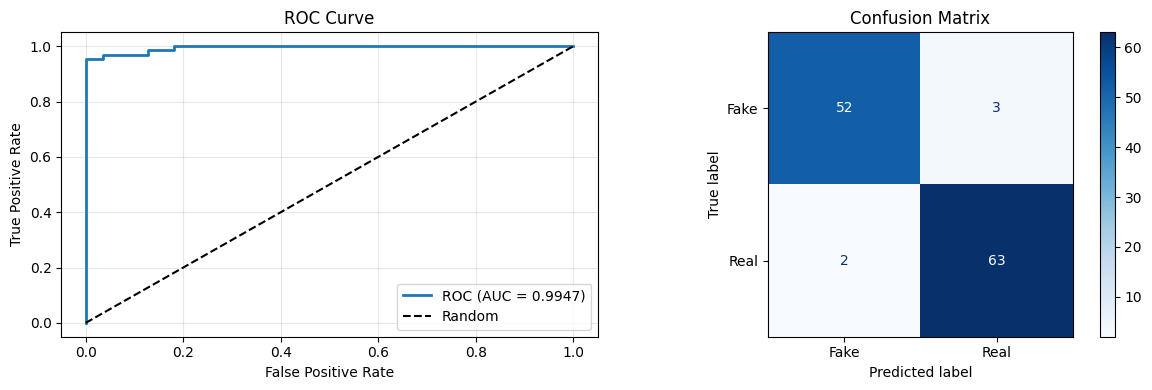

In [127]:
results = test_on_dataset(val_loader, model=model_3, dataset_name="Validation Set")

In [83]:
# import glob
# import random
# import os
# import shutil

# # Base directory
# base_dir = '/kaggle/input/datasets/adityal0/uncovai-dataset'

# # Subfolders inside the base directory
# subfolders = [
#     'diffusion_fake_images/diffusion_fake_images',
#     'diffusion_real_images',
#     'vae_fake_images',
#     'vae_real_images'
# ]

# # Output test set directory (single flat folder)
# test_set_dir = '/kaggle/working/test_set_1'
# os.makedirs(test_set_dir, exist_ok=True)

# # Number of samples per folder
# samples_per_folder = 10

# for sub in subfolders:
#     folder_path = os.path.join(base_dir, sub, '*')
    
#     # Get only files
#     all_files = [f for f in glob.glob(folder_path) if os.path.isfile(f)]
    
#     # Randomly pick samples
#     sampled_files = random.sample(all_files, min(samples_per_folder, len(all_files)))
    
#     # Copy each sampled file to the single test set directory
#     for file_path in sampled_files:
#         # Optional: rename to avoid duplicates
#         filename = os.path.basename(file_path)
#         shutil.copy(file_path, os.path.join(test_set_dir, filename))

# print(f"Test set created with all samples at: {test_set_dir}")

Test set created with all samples at: /kaggle/working/test_set_1
